In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# ─── Load Dataset ─────────────────────────────────────────────────────────────
bank = fetch_ucirepo(id=222)

X = bank.data.features
y = bank.data.targets

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
print("\nTarget column:", y.columns.tolist())
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (45211, 17)

Target column: ['y']

Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


# EDA — Dataset Description & Class Distribution
The Bank Marketing dataset contains 45,211 observations and 16 features (plus 1 binary target). It was collected from a Portuguese bank's direct phone marketing campaigns, where the goal was to predict whether a client would subscribe to a term deposit (y = yes/no).

Features include:
- Demographic: age, job, marital, education
- Financial: balance, default, housing, loan
- Campaign-related: contact, duration, campaign, pdays, previous, poutcome
- Temporal: day_of_week, month

Missing values are present in job, education, contact, and poutcome — these will be handled in preprocessing.

In [17]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Rows:     {df.shape[0]}")
print(f"Columns:  {df.shape[1]}")
print(f"Features: {df.shape[1] - 1}")
print(f"Target:   'y' (binary: yes/no — term deposit subscribed?)")

print("\n── Data Types ──────────────────────────────────────────")
print(df.dtypes)

print("\n── Missing Values ──────────────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n── Basic Statistics (Numeric) ──────────────────────────")
print(df.describe())

DATASET OVERVIEW
Rows:     45211
Columns:  17
Features: 16
Target:   'y' (binary: yes/no — term deposit subscribed?)

── Data Types ──────────────────────────────────────────
age            int64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day_of_week    int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
y                str
dtype: object

── Missing Values ──────────────────────────────────────
           Missing Count  Missing %
job                  288       0.64
education           1857       4.11
contact            13020      28.80
poutcome           36959      81.75

── Basic Statistics (Numeric) ──────────────────────────
                age        balance   day_of_week      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000  

── Class Distribution ──────────────────────────────────
  no:  39922  (88.3%)
  yes:   5289  (11.7%)


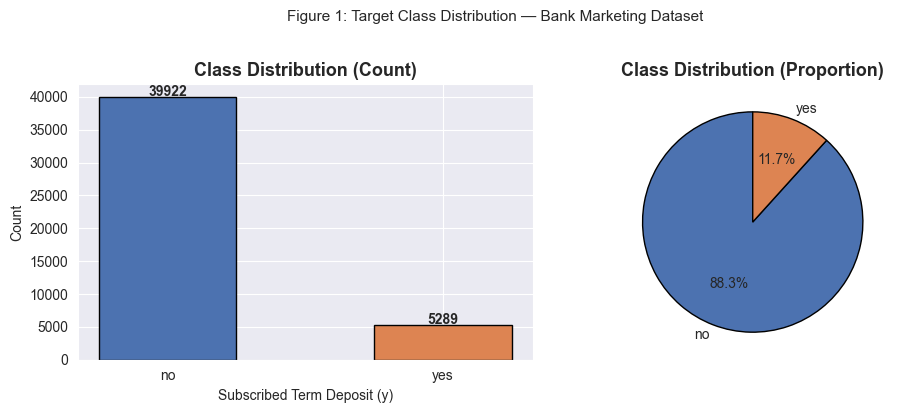

In [18]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("── Class Distribution ──────────────────────────────────")
for cls in target_counts.index:
    print(f"  {cls}: {target_counts[cls]:>6}  ({target_pct[cls]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed Term Deposit (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Target Class Distribution — Bank Marketing Dataset',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

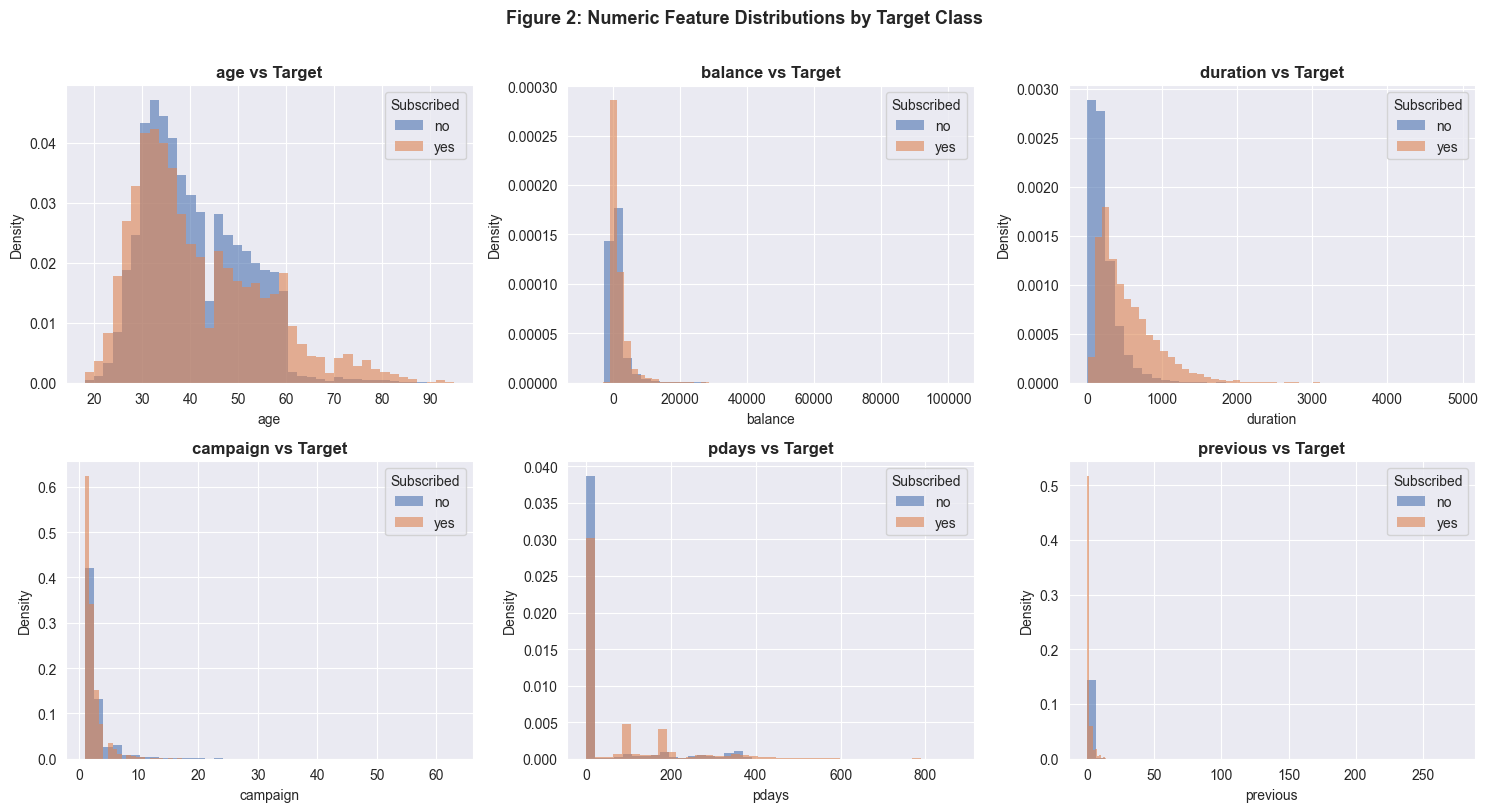

In [19]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
        subset = df[df['y'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, label=label,
                     color=color, edgecolor='none', density=True)
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(title='Subscribed')

plt.suptitle('Figure 2: Numeric Feature Distributions by Target Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

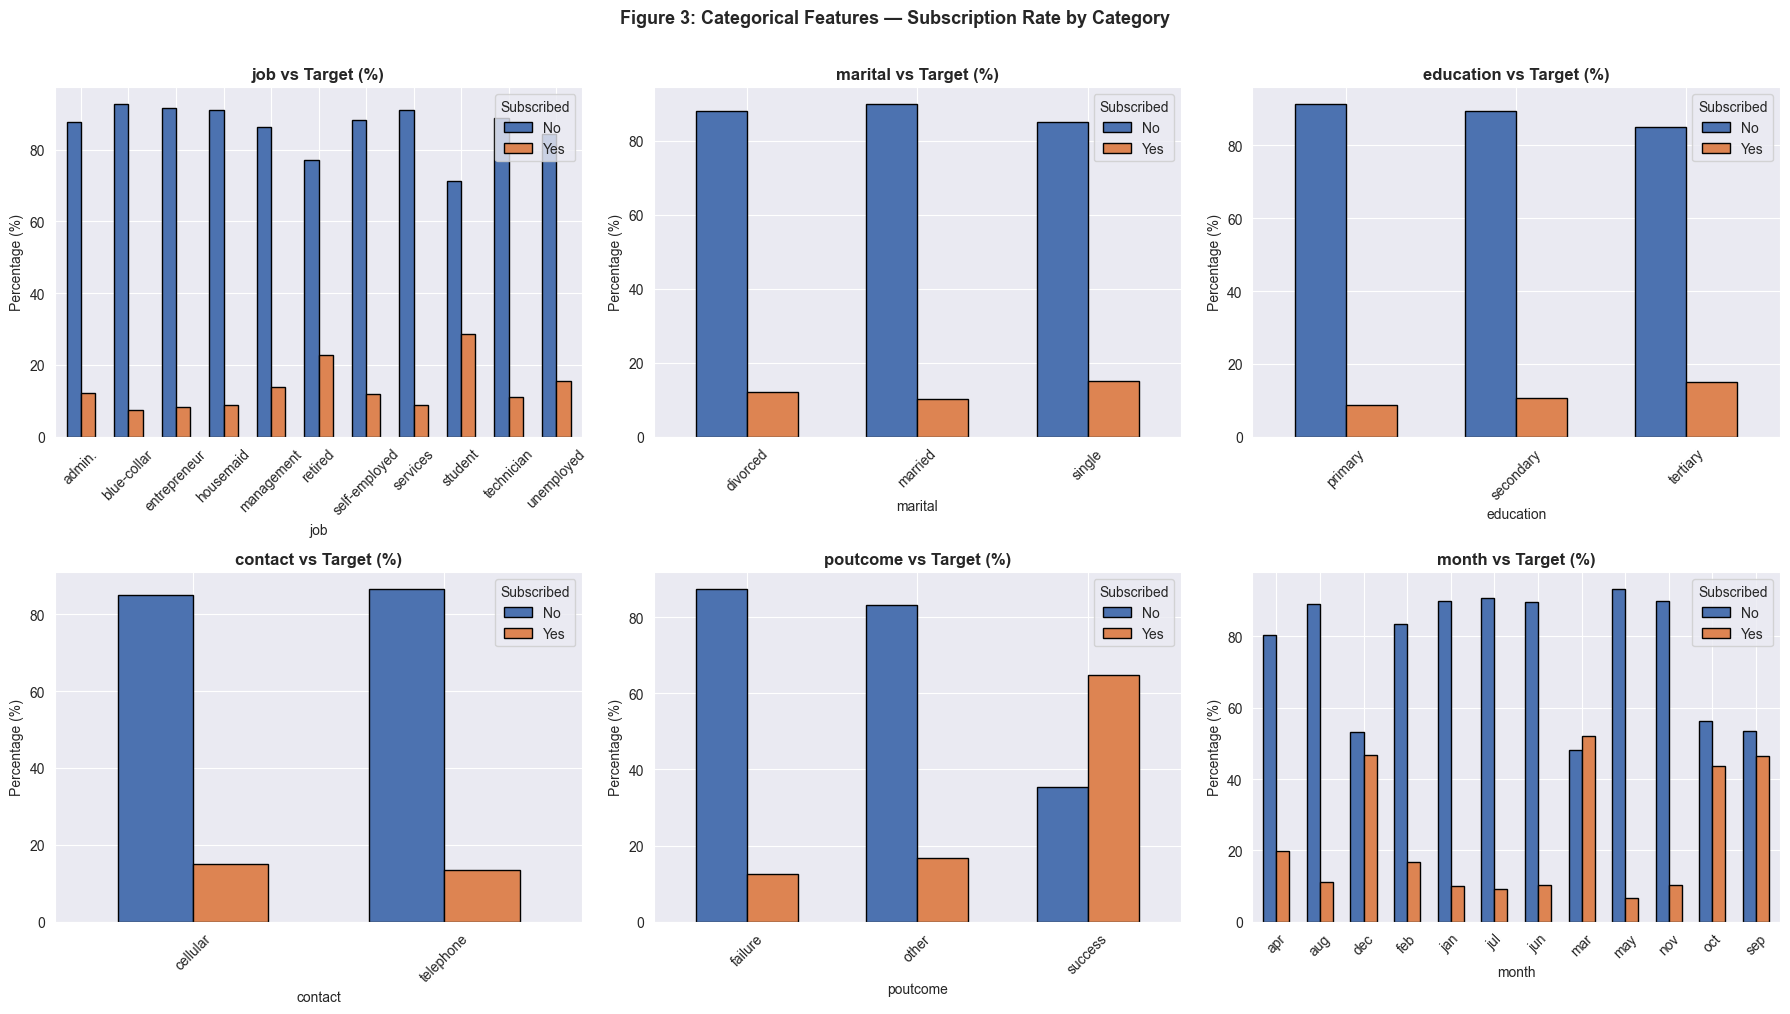

In [20]:
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'y']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'],
                edgecolor='black', width=0.6)
    axes[i].set_title(f'{col} vs Target (%)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Subscribed', labels=['No', 'Yes'])

plt.suptitle('Figure 3: Categorical Features — Subscription Rate by Category',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

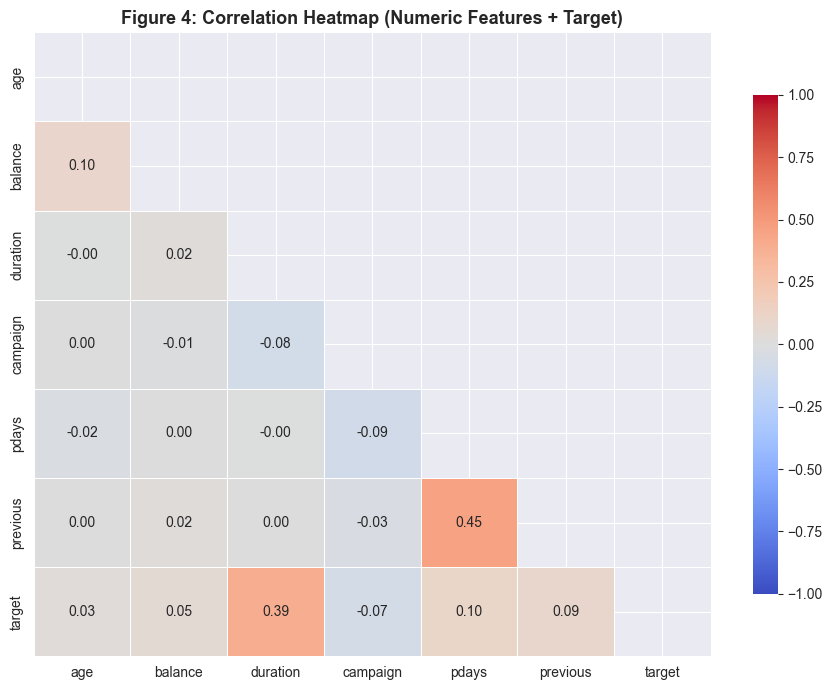

In [21]:
df_corr = df[numeric_cols].copy()
df_corr['target'] = (df['y'] == 'yes').astype(int)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Figure 4: Correlation Heatmap (Numeric Features + Target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# EDA — Feature Analysis
Numeric features (Figure 2):
- duration (last contact duration in seconds) shows the strongest visual separation — longer calls are much more likely to result in a subscription. However, this feature is only known after the call ends, so it should be noted as a potential data leakage risk in real deployment.
- balance and age show mild differences between classes, with slightly higher balances and older clients being marginally more likely to subscribe.
- campaign (number of contacts) shows that clients contacted fewer times are more likely to subscribe — excessive contact may hurt conversion.
- pdays and previous are heavily zero/negative-skewed, as most clients had no prior contact history.

Categorical features (Figure 3):
- poutcome = success is the strongest categorical predictor — clients with a successful previous campaign outcome subscribe at a dramatically higher rate (~65%).
- contact type shows meaningful differences — cellular contact has a notably higher subscription rate than telephone.
- month reveals seasonal patterns — May has the most contacts but not the highest conversion; March, September, October, and December show higher subscription rates.
- job and education show moderate variation — students and retired individuals tend to subscribe more than blue-collar or services workers.

Correlation heatmap (Figure 4):
- No severe multicollinearity among numeric features.
- duration has the highest positive correlation with the target (0.39).
- pdays and previous are moderately correlated with each other (0.45), which is expected since both capture prior contact history.
- All other inter-feature correlations are near zero, confirming the numeric features are largely independent.

In [22]:
# ─── Preprocessing ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ── 1. Encode target ──────────────────────────────────────────────────────────
df_clean = df.copy()
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)

# ── 2. Handle 'poutcome' — high missingness (81.75%), fill as 'unknown' ───────
df_clean['poutcome'] = df_clean['poutcome'].fillna('unknown')
df_clean['contact']  = df_clean['contact'].fillna('unknown')

# ── 3. Impute low-missingness categoricals with mode ─────────────────────────
for col in ['job', 'education']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# ── 4. Feature Engineering ────────────────────────────────────────────────────
# Flag: was client contacted before?
df_clean['was_contacted_before'] = (df_clean['pdays'] != -1).astype(int)
# Replace sentinel -1 in pdays with 0 (means never contacted)
df_clean['pdays'] = df_clean['pdays'].replace(-1, 0)

# ── 5. Ordinal encode 'education' ─────────────────────────────────────────────
edu_order = {'primary': 0, 'secondary': 1, 'tertiary': 2, 'unknown': -1}
df_clean['education'] = df_clean['education'].map(edu_order)

# ── 6. One-hot encode remaining categoricals ──────────────────────────────────
cat_ohe = ['job', 'marital', 'contact', 'month', 'poutcome',
           'default', 'housing', 'loan']
df_clean = pd.get_dummies(df_clean, columns=cat_ohe, drop_first=True)

print("Shape after encoding:", df_clean.shape)
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("\nColumn list:")
print(df_clean.columns.tolist())

Shape after encoding: (45211, 41)
Missing values remaining: 0

Column list:
['age', 'education', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'y', 'was_contacted_before', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'default_yes', 'housing_yes', 'loan_yes']


In [23]:
# ─── Split, Scale, SMOTE ──────────────────────────────────────────────
X = df_clean.drop('y', axis=1)
y = df_clean['y']

# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")

# ── Scale numeric features ────────────────────────────────────────────────────
numeric_cols = ['age', 'balance', 'duration', 'campaign',
                'pdays', 'previous', 'day_of_week']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# ── SMOTE on training set only ────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Train size: {X_train_sm.shape[0]}")
print(f"After SMOTE — Class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")

Train size: 36168 | Test size: 9043
Train class balance: {0: 31937, 1: 4231}

After SMOTE — Train size: 63874
After SMOTE — Class balance: {0: 31937, 1: 31937}


# Preprocessing
The following preprocessing steps were applied systematically:
1. Target encoding: The target y was binary-encoded as 1 = yes, 0 = no.
2. Missing value handling:
- poutcome (81.75% missing) and contact (28.80% missing) — filled with 'unknown' as a meaningful category, since missingness itself is informative (client had no prior outcome on record).
- job and education (< 5% missing) — imputed with mode.

3. Feature engineering:
- A new binary flag was_contacted_before was created from pdays (1 if previously contacted, 0 otherwise).
- The sentinel value -1 in pdays (meaning never contacted) was replaced with 0 for numeric consistency.

4. Encoding:
- education was ordinally encoded (primary=0, secondary=1, tertiary=2) as it has a natural order.
- All remaining categorical features were one-hot encoded with drop_first=True to avoid multicollinearity.

5. Train/test split: 80/20 stratified split to preserve class proportions.
6. Scaling: StandardScaler applied to numeric features — fitted on training data only to prevent data leakage.
7. SMOTE (Synthetic Minority Oversampling): Applied only to the training set to address the 88/12 class imbalance by generating synthetic minority samples. The test set is kept original to reflect real-world conditions.

In [24]:
# ─── Train All Models ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=31937/31937,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0),
    'KNN': KNeighborsClassifier(
        n_neighbors=11, n_jobs=-1),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced',
        probability=True, random_state=42)
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - t0
    trained[name] = model
    print(f"done in {elapsed:.1f}s")

print("\nAll models trained")

Training Logistic Regression... done in 0.1s
Training Decision Tree... done in 0.3s
Training Random Forest... done in 1.5s
Training XGBoost... done in 0.6s
Training KNN... done in 0.0s
Training SVM... done in 331.8s

All models trained


In [25]:
# ─── Compute All Metrics ─────────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay)

results = {}

for name, model in trained.items():
    y_pred      = model.predict(X_test)
    y_proba     = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
        'PR-AUC'   : average_precision_score(y_test, y_proba),
        'F1'       : f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
    }

results_df = pd.DataFrame(results).T.round(4)
print("=" * 60)
print("MODEL EVALUATION SUMMARY")
print("=" * 60)
print(results_df.sort_values('ROC-AUC', ascending=False).to_string())

MODEL EVALUATION SUMMARY
                     ROC-AUC  PR-AUC      F1  Precision  Recall
Random Forest         0.9268  0.5927  0.5942     0.5450  0.6531
XGBoost               0.9243  0.5965  0.5826     0.6055  0.5614
SVM                   0.9134  0.5572  0.5698     0.4482  0.7817
Logistic Regression   0.8880  0.5154  0.5505     0.4356  0.7476
KNN                   0.8797  0.4608  0.5258     0.4104  0.7316
Decision Tree         0.8731  0.5084  0.5390     0.4426  0.6890


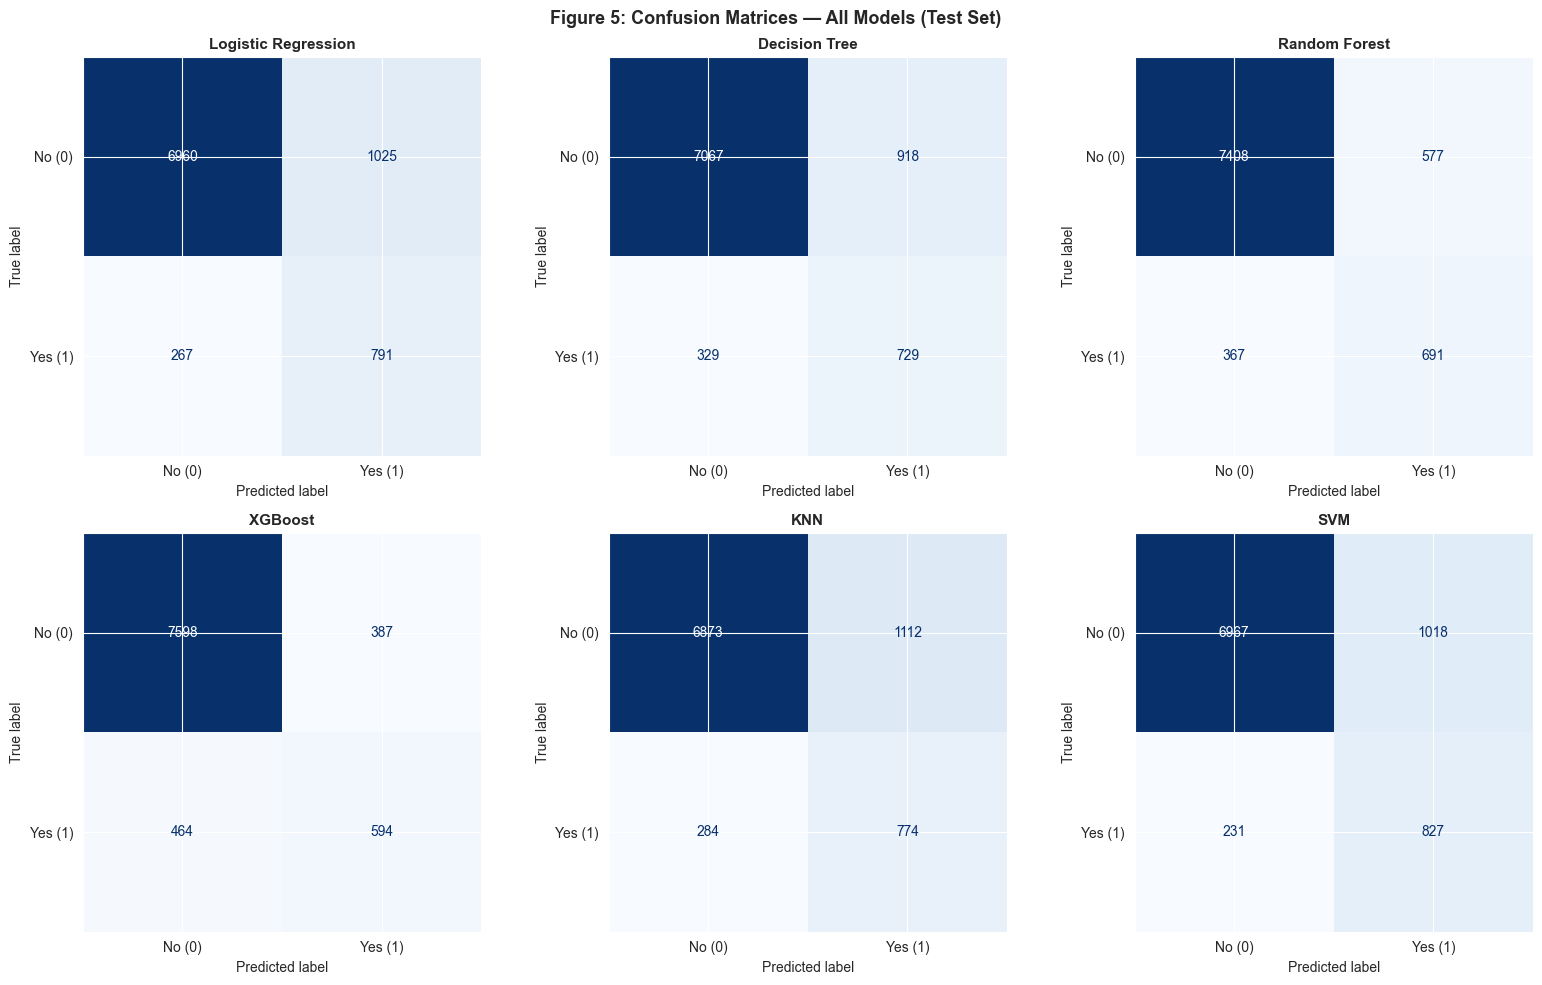

In [26]:
# ─── Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No (0)', 'Yes (1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=11)

plt.suptitle('Figure 5: Confusion Matrices — All Models (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

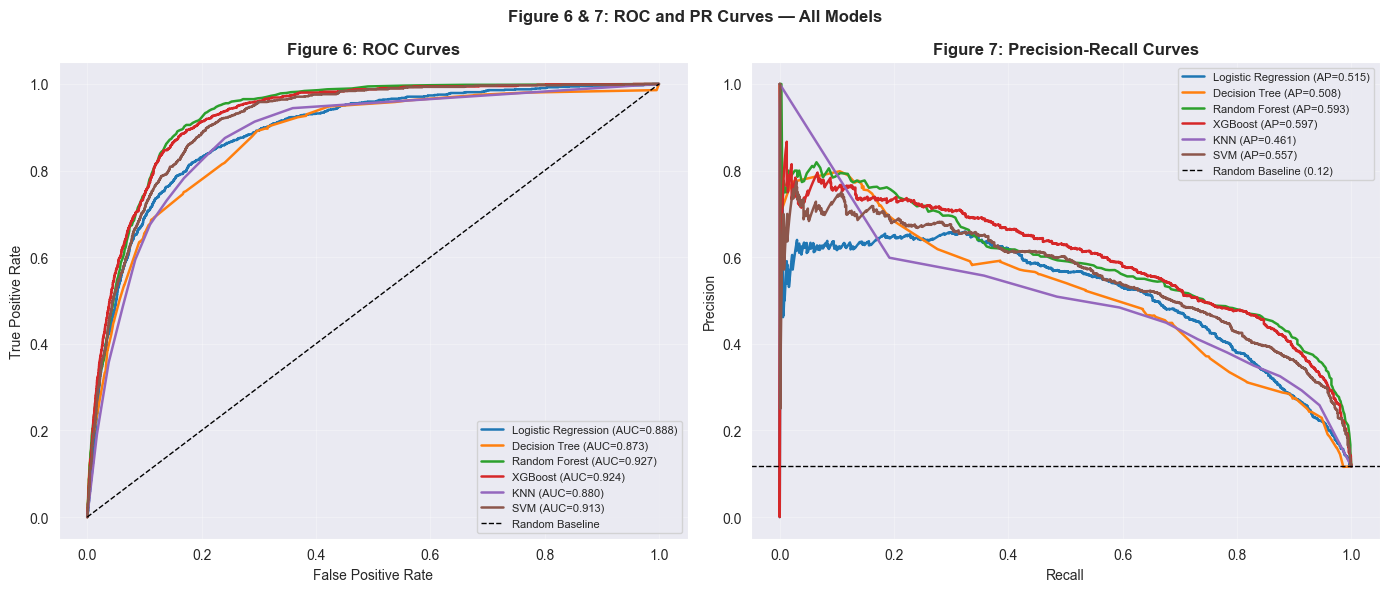

In [27]:
# ─── ROC Curves ──────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

for (name, model), color in zip(trained.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=1.8)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={pr_auc:.3f})', color=color, lw=1.8)

# ROC plot
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Figure 6: ROC Curves', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# PR plot
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1,
                label=f'Random Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Figure 7: Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Figure 6 & 7: ROC and PR Curves — All Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

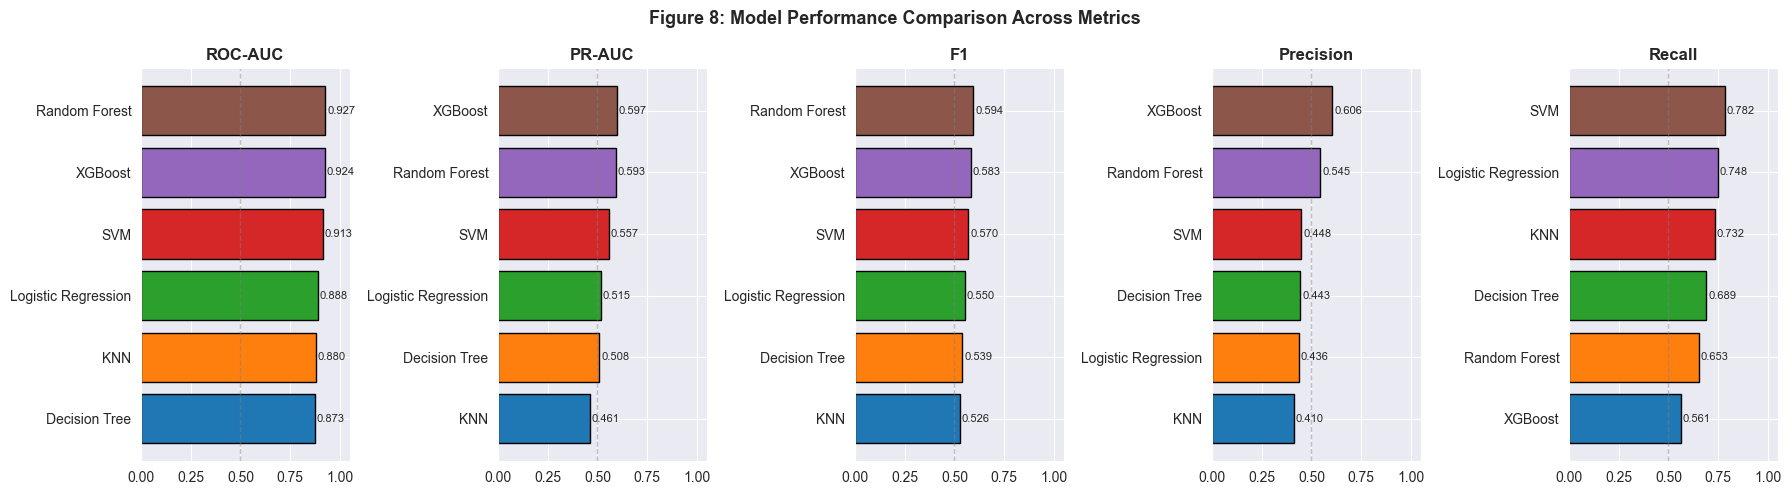

In [28]:
# ─── Metrics Comparison Bar Chart ────────────────────────────────────
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
results_plot = results_df[metrics_to_plot]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

for i, metric in enumerate(metrics_to_plot):
    vals = results_plot[metric].sort_values(ascending=True)
    bars = axes[i].barh(vals.index, vals.values, color=colors, edgecolor='black')
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_xlim(0, 1.05)
    axes[i].axvline(x=0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
    for bar, val in zip(bars, vals.values):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Figure 8: Model Performance Comparison Across Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Model Evaluation & Results Discussion

## Metrics Summary (Figure 8 + Table)
All six models were evaluated on the held-out test set (9,043 samples) using ROC-AUC, PR-AUC, F1, Precision, and Recall. The test set was kept in its original imbalanced form (88.3% / 11.7%) to reflect real-world conditions.

## Key Findings
- Random Forest achieved the highest ROC-AUC (0.927) and the best overall F1 score (0.594), making it the best-balanced model. It correctly identified 691 true subscribers while keeping false positives relatively low (577). Its PR-AUC of 0.593 confirms strong performance even under class imbalance.
- XGBoost was a close second with ROC-AUC of 0.924 and the highest PR-AUC (0.597), and the best Precision (0.606). This means when XGBoost predicts a subscription, it is correct most often — valuable in a campaign setting where contacting the wrong people has a cost.
- SVM showed the highest Recall (0.782) — it catches the most actual subscribers — but at the cost of low Precision (0.448), generating many false positives. This trade-off may be acceptable if the bank wants to cast a wide net and missing a subscriber is costly.
- Logistic Regression performed respectably with ROC-AUC of 0.888 and Recall of 0.748, offering a strong and interpretable baseline. In practice it would be a solid choice where model explainability is required.
- KNN had the lowest ROC-AUC (0.880) and PR-AUC (0.461), and was the weakest performer overall. It is sensitive to the high-dimensional one-hot encoded feature space, which hurts distance-based methods.
- Decision Tree had the lowest ROC-AUC (0.873) but is the most interpretable model. Its performance suffers compared to ensemble methods due to overfitting tendencies despite depth limiting.

## Confusion Matrix Analysis (Figure 5)
Looking at the confusion matrices, all models struggle more with false negatives (missing real subscribers) than false positives, which is expected given the original imbalance. XGBoost and Random Forest achieve the best balance between catching true positives and limiting false alarms.

## ROC & PR Curves (Figures 6 & 7)
The ROC curves confirm Random Forest and XGBoost as top performers, both well above the random baseline. The PR curves are more informative here due to class imbalance — all models substantially outperform the 0.12 random baseline, with XGBoost and Random Forest leading. The PR curves show that high precision is achievable at low recall thresholds, meaning confident predictions are reliable.

## Summary of Insights
- Best overall model: Random Forest (highest ROC-AUC, best F1)
- Best for precision-focused campaigns: XGBoost (highest Precision, highest PR-AUC)
- Best for recall-focused strategies: SVM (highest Recall — minimize missed subscribers)
- duration was the strongest individual predictor, but carries deployment risk as it is only known post-call
- poutcome = success and month were the most informative categorical features
- SMOTE effectively addressed class imbalance during training without leaking into evaluation
- Tree-based ensemble methods consistently outperformed linear and distance-based models on this dataset